In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import optuna


In [7]:
# Ejemplo: definir manualmente tipos de columnas

dtype_mapping = {
    # IDs - verificados contra los valores máximos
    'product_id': 'uint16',   # Máx 21299 < 65535
    'customer_id': 'uint16',  # Máx 10637 < 65535
    
    # Fechas en formato YYYYMM
    'periodo': 'uint32',
    'nacimiento_producto': 'uint32',
    'muerte_cliente': 'uint32',
    
    # Variables float - convertidas a 32 bits
    'periodo_producto': 'float32',
    'tn': 'float32',
    'cust_request_tn': 'float32',
    'lag_1m': 'float32',
    'lag_2m': 'float32',
    'lag_3m': 'float32',
    'lag_11m': 'float32',
    'rolling_3m_mean': 'float32',
    'rolling_6m_mean': 'float32',
    'rolling_12m_mean': 'float32',
    'annual_trend': 'float32',
    'seasonal_variation': 'float32',
    'size_vs_category': 'float32',
    
    # Variables enteras - ajustadas al rango
    'cust_request_qty': 'float32',   # Máx 142 < 255
    'sku_size': 'float32',         # Máx 10000 < 65535
    
    # Variables categóricas
    'cat1': 'category'
}

df = pd.read_csv('../datasets/dt_fe.csv', sep=',', dtype=dtype_mapping)

In [8]:
# Codificar categóricas
cat_cols = ['cat1', 'cat2', 'cat3', 'brand', 'plan_precios_cuidados']
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        

df = df.drop(['periodo_dt'], axis=1, errors='ignore')
df_kgl = df[df["periodo"] == 201912]
df = df[~df["periodo"].isin([201911, 201912])]
# Separar features y target
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

In [9]:


# Ruta a la base de datos
DB_PATH = "optuna_storage/optuna_simple.db"

# Cargar el estudio almacenado
study = optuna.load_study(
    study_name=None,  # Usar None si solo hay un estudio en la DB, o especificar el nombre
    storage=f"sqlite:///{DB_PATH}"
)

# Obtener los mejores hiperparámetros
best_params = study.best_params
best_value = study.best_value

print("Mejores hiperparámetros encontrados:")
print(best_params)
print(f"Mejor valor objetivo: {best_value}")

[I 2025-05-31 11:21:55,276] Study name was omitted but trying to load 'lightgbm_sin_cv' because that was the only study found in the storage.


Mejores hiperparámetros encontrados:
{'num_leaves': 232, 'learning_rate': 0.004648054506981842, 'feature_fraction': 0.5703341269914189, 'bagging_fraction': 0.5990528265244626, 'bagging_freq': 6, 'min_child_samples': 100, 'lambda_l1': 3.392866762405977e-06, 'lambda_l2': 0.0011444820553097982, 'max_depth': 11}
Mejor valor objetivo: 0.04338014011658282


In [10]:

# Entrenar con los mejores hiperparámetros
best_params = study.best_params.copy()
best_params.update({
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "n_jobs": -1,
    "seed": 42
})

# Entrenar una vez el modelo con esos parámetros (ej. sobre X_train si no querés usar todo)
model = lgb.train(
    best_params,
    lgb.Dataset(X_train, label=y_train),
    valid_sets=[lgb.Dataset(X_val, label=y_val)],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)


# Asegurar las mismas columnas
X_kgl = df_kgl[X.columns]  # Misma estructura

# === 9. Hacer predicción sobre nuevos datos ===
preds_kgl = model.predict(X_kgl)

# Mostrar o guardar resultados
print("Predicciones para periodo 201912:")
print(preds_kgl)

Predicciones para periodo 201912:
[-3.97597137e+01 -1.23315145e+01  4.73124575e+00 ...  3.89994305e-03
  3.89994305e-03  3.89994305e-03]


In [11]:
productos_ok = pd.read_csv("https://storage.googleapis.com/open-courses/austral2025-af91/labo3v/product_id_apredecir201912.txt", sep="\t")
result = pd.DataFrame({"product_id": X_kgl["product_id"], "tn": X_kgl["tn"],  "ypred": preds_kgl})
result["tn"] = result["ypred"] + result["tn"]
result = result[result["product_id"].isin(productos_ok["product_id"])]
result = result.groupby("product_id").agg({"tn":"sum"}).reset_index()
result

,product_id,tn
0,20001,1305.879753
1,20002,1071.949018
2,20003,770.124384
3,20004,588.465617
4,20005,494.686746
...,...,...
775,21263,2.321648
776,21265,2.288439
777,21266,2.291880
778,21267,2.267443


In [12]:
result.to_csv("../results/resultados-31-05_2.csv", index=False,sep=",")

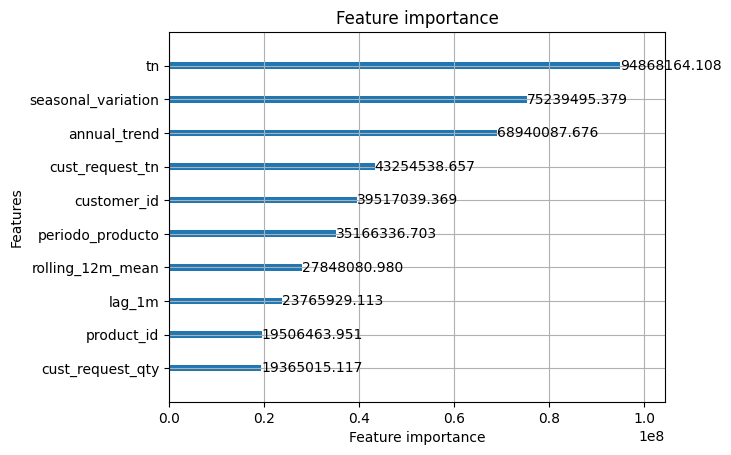

In [14]:
import matplotlib.pyplot as plt
from lightgbm import plot_importance  # Importación específica
# Visualizar importancia de características
plot_importance(model, importance_type='gain', max_num_features=10)  # Usar la función importada
plt.show()